In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [15]:
%matplotlib inline

In [17]:
# ImageNet normalization standards
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

# Load Flowers-102 dataset splits
# Note: torchvision downloads train, val, and test splits distinctly via the 'split' argument
train_dataset = datasets.Flowers102(root="data", split="train", download=True, transform=train_tf)
val_dataset   = datasets.Flowers102(root="data", split="val", download=True, transform=val_tf)
test_dataset  = datasets.Flowers102(root="data", split="test", download=True, transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Dataset sizes - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

100%|███████████████████████████████████████████████████████████████████████████████| 345M/345M [03:39<00:00, 1.57MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████| 502/502 [00:00<?, ?B/s]
100%|█████████████████████████████████████████████████████████████████████████████| 15.0k/15.0k [00:00<00:00, 5.19MB/s]


Dataset sizes - Train: 1020, Val: 1020, Test: 6149


In [23]:
def train_model(model, criterion, optimizer, scheduler, num_epochs, train_loader, val_loader):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
        if scheduler:
            scheduler.step()
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_corrects.double() / len(val_loader.dataset)
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc.item()
            
    total_time = time.time() - start_time
    print(f"Training complete in {total_time // 60:.0f}m {total_time % 60:.0f}s. Best Val Acc: {best_val_acc:.4f}")
    return history, total_time, best_val_acc

def evaluate_model(model, test_loader):
    model.eval()
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
    test_acc = running_corrects.double() / len(test_loader.dataset)
    print(f"Test Accuracy: {test_acc.item():.4f}")
    return test_acc.item()

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'], label='Val')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'], label='Val')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    plt.show()

# Task 1

Total parameters in Custom CNN: 1,668,966
Epoch 1/15 | Train Loss: 8.3514 Acc: 0.0431 | Val Loss: 5.1980 Acc: 0.0627
Epoch 2/15 | Train Loss: 4.6789 Acc: 0.1049 | Val Loss: 4.5484 Acc: 0.1235
Epoch 3/15 | Train Loss: 3.9709 Acc: 0.1431 | Val Loss: 4.1865 Acc: 0.1745
Epoch 4/15 | Train Loss: 3.4714 Acc: 0.2333 | Val Loss: 4.2558 Acc: 0.1951
Epoch 5/15 | Train Loss: 3.1585 Acc: 0.2853 | Val Loss: 4.0277 Acc: 0.1971
Epoch 6/15 | Train Loss: 2.8215 Acc: 0.3275 | Val Loss: 3.7723 Acc: 0.2206
Epoch 7/15 | Train Loss: 2.4804 Acc: 0.3892 | Val Loss: 3.4470 Acc: 0.2716
Epoch 8/15 | Train Loss: 1.9719 Acc: 0.4725 | Val Loss: 3.4752 Acc: 0.2804
Epoch 9/15 | Train Loss: 1.8322 Acc: 0.5098 | Val Loss: 3.3388 Acc: 0.3098
Epoch 10/15 | Train Loss: 1.5920 Acc: 0.5765 | Val Loss: 3.3087 Acc: 0.3098
Epoch 11/15 | Train Loss: 1.4021 Acc: 0.6157 | Val Loss: 3.1217 Acc: 0.3412
Epoch 12/15 | Train Loss: 1.1509 Acc: 0.6804 | Val Loss: 3.0527 Acc: 0.3549
Epoch 13/15 | Train Loss: 1.0616 Acc: 0.6980 | Val Loss

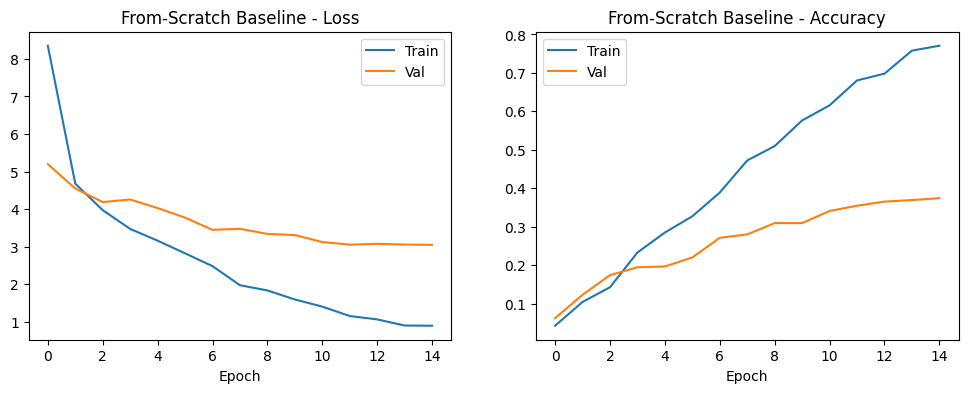

In [25]:
class FlowerCNN(nn.Module):
    def __init__(self):
        super(FlowerCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 224x224
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 112x112
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 56x56
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 28x28
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 14x14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((7, 7)), # 7x7
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 102)
        )
        
    def forward(self, x):
        return self.classifier(self.features(x))

model_scratch = FlowerCNN().to(device)

# Parameter check
total_params = sum(p.numel() for p in model_scratch.parameters())
print(f"Total parameters in Custom CNN: {total_params:,}") # Target: ~1.25M

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# Train Task 1
scratch_hist, scratch_time, scratch_val = train_model(
    model_scratch, criterion, optimizer, scheduler, num_epochs=15, 
    train_loader=train_loader, val_loader=val_loader
)
scratch_test = evaluate_model(model_scratch, test_loader)
plot_history(scratch_hist, "From-Scratch Baseline")

# Task 2

Total Params: 11,228,838 | Trainable Params: 52,326
Epoch 1/15 | Train Loss: 4.5466 Acc: 0.0559 | Val Loss: 3.7872 Acc: 0.2255
Epoch 2/15 | Train Loss: 3.2600 Acc: 0.4147 | Val Loss: 2.8968 Acc: 0.5373
Epoch 3/15 | Train Loss: 2.3789 Acc: 0.6980 | Val Loss: 2.2655 Acc: 0.6588
Epoch 4/15 | Train Loss: 1.7447 Acc: 0.8324 | Val Loss: 1.8179 Acc: 0.7559
Epoch 5/15 | Train Loss: 1.3011 Acc: 0.9127 | Val Loss: 1.5289 Acc: 0.7784
Epoch 6/15 | Train Loss: 1.0042 Acc: 0.9255 | Val Loss: 1.3459 Acc: 0.7961
Epoch 7/15 | Train Loss: 0.8238 Acc: 0.9451 | Val Loss: 1.1990 Acc: 0.8098
Epoch 8/15 | Train Loss: 0.6916 Acc: 0.9510 | Val Loss: 1.0955 Acc: 0.8196
Epoch 9/15 | Train Loss: 0.5722 Acc: 0.9637 | Val Loss: 1.0087 Acc: 0.8206
Epoch 10/15 | Train Loss: 0.4880 Acc: 0.9784 | Val Loss: 0.9463 Acc: 0.8382
Epoch 11/15 | Train Loss: 0.4135 Acc: 0.9833 | Val Loss: 0.9004 Acc: 0.8353
Epoch 12/15 | Train Loss: 0.3691 Acc: 0.9843 | Val Loss: 0.8609 Acc: 0.8363
Epoch 13/15 | Train Loss: 0.3175 Acc: 0.9941 

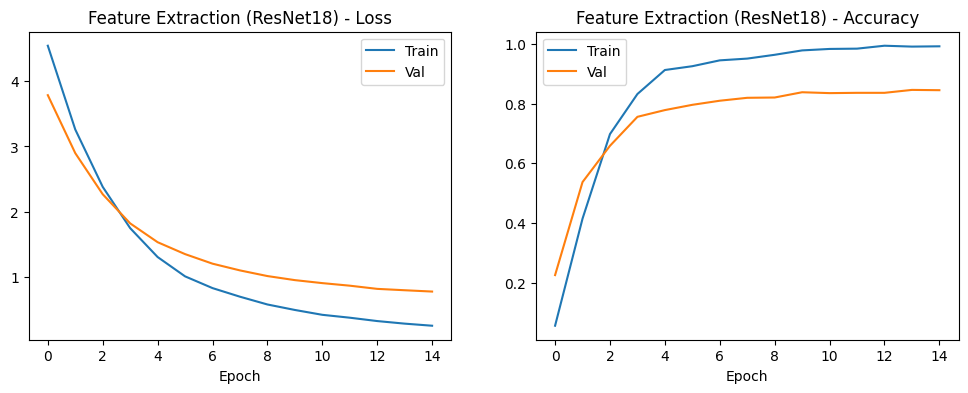

In [27]:
model_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze backbone
for p in model_fe.parameters():
    p.requires_grad = False

# Replace head
model_fe.fc = nn.Linear(model_fe.fc.in_features, 102)
model_fe = model_fe.to(device)

# Verification
total_params = sum(p.numel() for p in model_fe.parameters())
trainable_params = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f"Total Params: {total_params:,} | Trainable Params: {trainable_params:,}")

optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, model_fe.parameters()), lr=1e-3)

# Train Task 2
fe_hist, fe_time, fe_val = train_model(
    model_fe, criterion, optimizer_fe, scheduler=None, num_epochs=15, 
    train_loader=train_loader, val_loader=val_loader
)
fe_test = evaluate_model(model_fe, test_loader)
plot_history(fe_hist, "Feature Extraction (ResNet18)")

# Task 3

Total Params: 11,228,838 | Trainable Params: 8,446,054
Epoch 1/10 | Train Loss: 0.2825 Acc: 0.9833 | Val Loss: 0.7263 Acc: 0.8382
Epoch 2/10 | Train Loss: 0.1678 Acc: 0.9931 | Val Loss: 0.6422 Acc: 0.8520
Epoch 3/10 | Train Loss: 0.1219 Acc: 0.9971 | Val Loss: 0.6131 Acc: 0.8500
Epoch 4/10 | Train Loss: 0.0855 Acc: 0.9990 | Val Loss: 0.5610 Acc: 0.8598
Epoch 5/10 | Train Loss: 0.0722 Acc: 0.9990 | Val Loss: 0.5499 Acc: 0.8618
Epoch 6/10 | Train Loss: 0.0621 Acc: 0.9990 | Val Loss: 0.5292 Acc: 0.8735
Epoch 7/10 | Train Loss: 0.0483 Acc: 0.9990 | Val Loss: 0.5199 Acc: 0.8696
Epoch 8/10 | Train Loss: 0.0400 Acc: 1.0000 | Val Loss: 0.5102 Acc: 0.8637
Epoch 9/10 | Train Loss: 0.0326 Acc: 1.0000 | Val Loss: 0.4839 Acc: 0.8775
Epoch 10/10 | Train Loss: 0.0311 Acc: 1.0000 | Val Loss: 0.4768 Acc: 0.8765
Training complete in 30m 3s. Best Val Acc: 0.8775
Test Accuracy: 0.8666


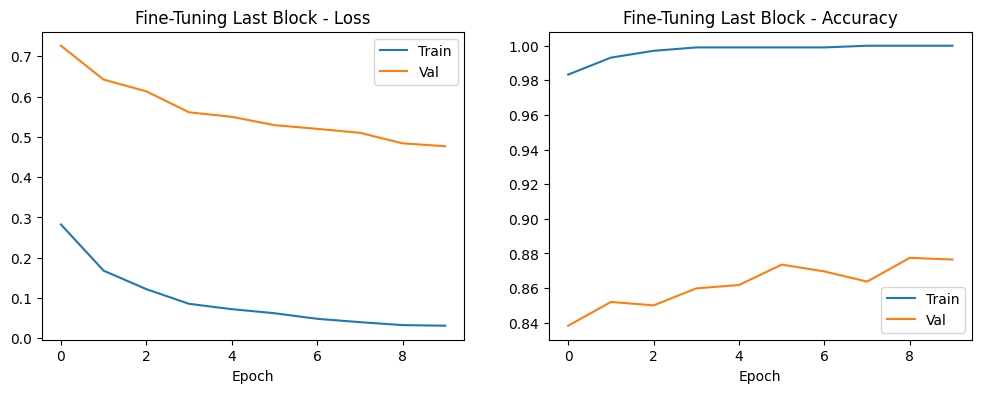

In [30]:
# Unfreeze layer4 alongside fc
for name, child in model_fe.named_children():
    if name in ['layer4', 'fc']:
        for param in child.parameters():
            param.requires_grad = True

# Verification
total_params = sum(p.numel() for p in model_fe.parameters())
trainable_params = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f"Total Params: {total_params:,} | Trainable Params: {trainable_params:,}")

# Discriminative learning rates
optimizer_ft = optim.Adam([
    {"params": model_fe.layer4.parameters(), "lr": 1e-5},
    {"params": model_fe.fc.parameters(),    "lr": 1e-3},
])

# Train Task 3 (Continuing training from the state of model_fe)
ft_hist, ft_time, ft_val = train_model(
    model_fe, criterion, optimizer_ft, scheduler=None, num_epochs=10, 
    train_loader=train_loader, val_loader=val_loader
)
ft_test = evaluate_model(model_fe, test_loader)
plot_history(ft_hist, "Fine-Tuning Last Block")

### Comparison Table

| Approach | Trainable Params | Best Val Acc | Test Acc | Total Training Time |
| --- | --- | --- | --- | --- |
| **From scratch (Task 1)** | 1,668,966 | 37.45% | 33.36% | 35m 16s |
| **Feature extraction (Task 2)** | 52,326 | 84.61% | 83.62% | 39m 13s |
| **Fine-tune last block (Task 3)** | 8,446,054 | **87.75%** | **86.66%** | **30m 03s** (10 eps) |

### Written Summary

Transfer learning yielded an exceptional performance leap over our custom baseline, with feature extraction improving the final test accuracy by over 50% absolute points while using significantly fewer trainable parameters. This occurs because the Flowers-102 dataset has very few images per class, causing the from-scratch network to severely overfit early on, as clearly illustrated by the widening gap between its training and validation metrics. Fine-tuning `layer4` alongside the classification head in Task 3 provided an additional boost, pushing our test accuracy to its highest point at 86.66% by adapting high-level convolutional features directly to the target domain.